<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Desafío 3: Modelo de lenguaje con tokenización por caracteres

**Asignatura:** Procesamiento de Lenguaje Natural I (CEIA - FIUBA)

**Autor:** Leandro A. Britez

**Corpus de estudio:** `corpus_JulioVerne.txt`, correspondiente al texto completo de *Viaje al centro de la Tierra* de Julio Verne, con 4.602 líneas.

---

### Objetivo

El objetivo de este desafío es construir un **modelo de lenguaje a nivel de caracteres** utilizando redes neuronales recurrentes. A diferencia del Desafío 2, donde se trabajó con *word embeddings* (Word2Vec) para capturar relaciones semánticas entre **palabras**, aquí se opera a nivel de **caracteres individuales**.

**Diferencia clave respecto al Desafío 2:**
- En el Desafío 2 se entrenaron embeddings de palabras con Gensim (Skip-gram) sobre el mismo corpus de Julio Verne, obteniendo relaciones semánticas entre términos como *profesor*, *axel*, *volcán*, *tierra*.
- En este Desafío 3, el modelo aprende a **predecir el próximo carácter** dada una secuencia de contexto, lo que le permite generar texto nuevo carácter a carácter.

**Ventajas del enfoque char-level:**
- Vocabulario muy reducido (~70 caracteres vs. miles de palabras).
- No hay problema de *out-of-vocabulary* (OOV).
- El modelo puede generar cualquier palabra, incluso inventadas.

**Corpus:** `corpus_JulioVerne.txt` — "Viaje al Centro de la Tierra" de Julio Verne (el mismo utilizado en el Desafío 2).

### Plan de trabajo
1. Preprocesar y tokenizar el corpus por caracteres.
2. Estructurar el dataset en formato *many-to-many*.
3. Entrenar tres arquitecturas: **SimpleRNN**, **LSTM** y **GRU**.
4. Evaluar con **perplejidad** sobre datos de validación.
5. Generar secuencias con **greedy search** y **beam search** (determinístico y estocástico), analizando el efecto de la **temperatura**.


### Perplejidad como métrica de evaluación

La **perplejidad** (perplexity, PPL) es la métrica estándar para evaluar modelos de lenguaje. Mide cuánto "sorprendido" está el modelo ante los datos reales:

$$PPL = \exp\left(-\frac{1}{N}\sum_{i=1}^{N}\log P(x_i | x_{<i})\right)$$

- Una perplejidad **más baja** indica un mejor modelo.
- Intuitivamente, si el vocabulario tiene $V$ caracteres, un modelo aleatorio tendría PPL = $V$. Un buen modelo debería estar muy por debajo de ese valor.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, SimpleRNN, Embedding, Dropout, TimeDistributed, CategoryEncoding
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.utils import pad_sequences
from scipy.special import softmax

import warnings
warnings.filterwarnings('ignore')

# Verificar GPU disponible
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Carga y preprocesamiento del corpus

Se utiliza el mismo corpus de Julio Verne ("Viaje al Centro de la Tierra") empleado en el Desafío 2. En esta oportunidad, en lugar de tokenizar por palabras como se hizo con Gensim, se trabaja directamente con los **caracteres individuales** del texto.

El preprocesamiento es mínimo: se convierte todo a minúsculas para reducir el tamaño del vocabulario de caracteres.


In [3]:
import os
import platform
import urllib.request

file_path = 'corpus_JulioVerne.txt'

# Intentar descargar el corpus si no existe (compatible con Colab)
if not os.path.exists(file_path):
    try:
        url = 'https://raw.githubusercontent.com/leandroabritez/NLP_TP_03_private/main/corpus_JulioVerne.txt'
        print(f"Intentando descargar corpus desde {url}...")
        urllib.request.urlretrieve(url, file_path)
        print("Descarga completada.")
    except Exception as e:
        print(f"No se pudo descargar automáticamente (el repositorio es privado).\nError: {e}")
        print("\nPor favor, si estás en Colab, sube manualmente el archivo 'corpus_JulioVerne.txt' al entorno de ejecución.")
        print("Puedes usar la barra lateral izquierda (Archivos -> Subir al almacenamiento de sesión).")
else:
    print("El corpus ya se encuentra disponible.")

if os.path.exists(file_path):
    # Lectura y preprocesamiento
    with open(file_path, 'r', encoding='utf-8') as f:
        article_text = f.read()

    # Pasar todo a minúsculas
    article_text = article_text.lower()

    print(f"Longitud total del texto: {len(article_text):,} caracteres")
    print(f"\nPrimeros 500 caracteres:")
    print(article_text[:500])
else:
    print("Esperando el archivo...")


El corpus ya se encuentra disponible.
Longitud total del texto: 427,067 caracteres

Primeros 500 caracteres:
capítulo 1
el domingo 24 de mayo de 1863, mi tío, el profesor lidenbrock, entró rápidamente a su hogar, situado en el número 19 de la könig‑strasse, una de las calles más tradicionales del barrio antiguo de hamburgo.

marta, su excelente criada, se preocupó sobremanera, creyendo que se había retrasado, pues apenas empezaba a cocinar la comida en el hornillo.

“bueno” —pensé para mí—, “si mi tío viene con hambre, se va a armar la de san quintín; porque no conozco a otro hombre de menos paciencia”


Caracteres únicos en el vocabulario: 75
Caracteres: ['\n', ' ', '!', "'", '(', ')', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '¡', '«', '\xad', '°', '»', '¿', 'á', 'â', 'ä', 'é', 'í', 'ñ', 'ó', 'ö', 'ú', 'ü', 'œ', '‑', '–', '—', '―', '“', '”', '…', 'ﬂ']


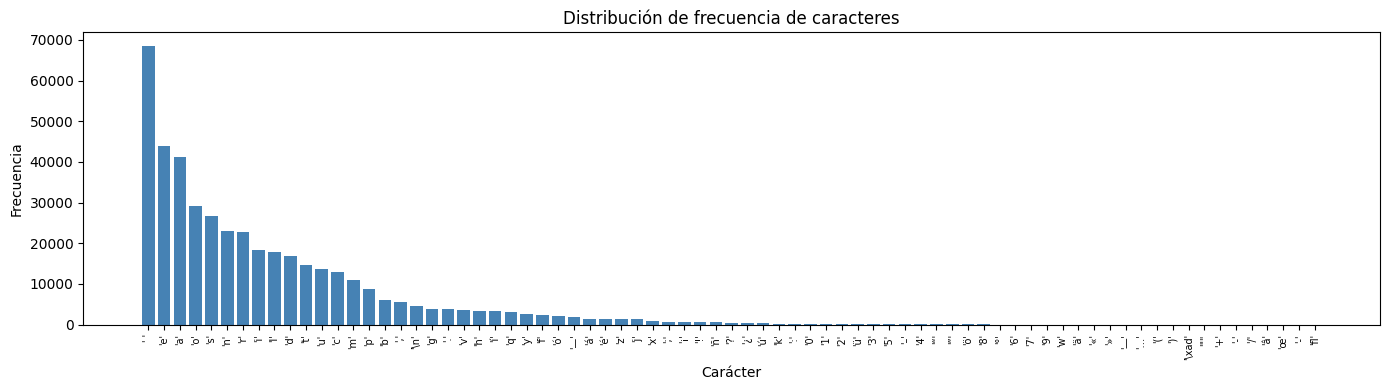


Top 10 caracteres más frecuentes:
     ' ': 68,457 (16.0%)
     'e': 44,015 (10.3%)
     'a': 41,156 (9.6%)
     'o': 29,186 (6.8%)
     's': 26,803 (6.3%)
     'n': 23,057 (5.4%)
     'r': 22,685 (5.3%)
     'i': 18,446 (4.3%)
     'l': 17,910 (4.2%)
     'd': 16,757 (3.9%)


In [4]:
# Estadísticas del corpus
if 'article_text' in locals():
    chars_vocab = sorted(set(article_text))
    vocab_size = len(chars_vocab)

    print(f"Caracteres únicos en el vocabulario: {vocab_size}")
    print(f"Caracteres: {chars_vocab}")

    # Distribución de frecuencia de caracteres
    char_freq = {ch: article_text.count(ch) for ch in chars_vocab}
    char_freq_sorted = dict(sorted(char_freq.items(), key=lambda x: x[1], reverse=True))

    plt.figure(figsize=(14, 4))
    plt.bar(range(len(char_freq_sorted)), list(char_freq_sorted.values()), color='steelblue')
    plt.xticks(range(len(char_freq_sorted)), [repr(c) for c in char_freq_sorted.keys()], rotation=90, fontsize=7)
    plt.title('Distribución de frecuencia de caracteres')
    plt.xlabel('Carácter')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

    # Top 10 caracteres
    print("\nTop 10 caracteres más frecuentes:")
    for i, (ch, freq) in enumerate(list(char_freq_sorted.items())[:10]):
        print(f"  {repr(ch):>6s}: {freq:>6,d} ({100*freq/len(article_text):.1f}%)")

El Espacio   (16%) y las vocales e, a, o lideran la lista, seguidas casi de inmediato por las consonantes más comunes (s, n, r). Esto significa que el modelo aprenderá rápidamente a generar espacios entre palabras y combinaciones silábicas típicas del español, y le costará más generar palabras con k o w.

## 2. Tokenización por caracteres

A diferencia del Desafío 2, donde se usó `text_to_word_sequence` de Keras para obtener tokens de palabras, aquí cada **carácter** es un token. Se construyen diccionarios `char2idx` e `idx2char` para la conversión.


In [5]:
if 'chars_vocab' in locals():
    # Diccionarios de mapeo carácter <-> índice
    char2idx = {ch: idx for idx, ch in enumerate(chars_vocab)}
    idx2char = {idx: ch for ch, idx in char2idx.items()}

    print(f"Tamaño del vocabulario: {vocab_size}")
    print(f"\nEjemplo de mapeo (primeros 10):")
    for ch in list(char2idx.keys())[:10]:
        print(f"  {repr(ch):>6s} -> {char2idx[ch]}")

Tamaño del vocabulario: 75

Ejemplo de mapeo (primeros 10):
    '\n' -> 0
     ' ' -> 1
     '!' -> 2
     "'" -> 3
     '(' -> 4
     ')' -> 5
     '+' -> 6
     ',' -> 7
     '-' -> 8
     '.' -> 9


In [6]:
if 'article_text' in locals():
    # Tokenizar el texto completo
    tokenized_text = [char2idx[ch] for ch in article_text]

    print(f"Longitud del texto tokenizado: {len(tokenized_text):,}")
    print(f"Primeros 100 tokens: {tokenized_text[:100]}")
    print(f"\nDecodificado: '{article_text[:100]}'")

Longitud del texto tokenizado: 427,067
Primeros 100 tokens: [26, 24, 39, 60, 43, 44, 35, 38, 1, 12, 0, 28, 35, 1, 27, 38, 36, 32, 37, 30, 38, 1, 13, 15, 1, 27, 28, 1, 36, 24, 48, 38, 1, 27, 28, 1, 12, 19, 17, 14, 7, 1, 36, 32, 1, 43, 60, 38, 7, 1, 28, 35, 1, 39, 41, 38, 29, 28, 42, 38, 41, 1, 35, 32, 27, 28, 37, 25, 41, 38, 26, 34, 7, 1, 28, 37, 43, 41, 62, 1, 41, 56, 39, 32, 27, 24, 36, 28, 37, 43, 28, 1, 24, 1, 42, 44, 1, 31, 38, 30]

Decodificado: 'capítulo 1
el domingo 24 de mayo de 1863, mi tío, el profesor lidenbrock, entró rápidamente a su hog'


## 3. Estructuración del dataset

### Enfoque many-to-many

Se estructura el problema como **many-to-many**:
- **Entrada**: secuencia de tokens $[x_0, x_1, ..., x_N]$
- **Target**: secuencia desplazada $[x_1, x_2, ..., x_{N+1}]$

La ventaja de este enfoque (en lugar de many-to-one) es que para cada token de target se propaga una señal de gradiente, lo que resulta en un entrenamiento más eficiente.

Se elige un **tamaño de contexto de 100 caracteres**, siguiendo la sugerencia del template. En un modelo char-level, todo el corpus es un documento continuo y el contexto se puede elegir con libertad.


In [13]:
if 'tokenized_text' in locals():
    # Tamaño del contexto
    max_context_size = 100

    # Separar train/val (90%/10% temporal)
    p_val = 0.1
    num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

    train_text = tokenized_text[:-num_val * max_context_size]
    val_text = tokenized_text[-num_val * max_context_size:]

    print(f"Tamaño de contexto: {max_context_size} caracteres")
    print(f"Total de caracteres tokenizados: {len(tokenized_text):,}")
    print(f"Caracteres en train: {len(train_text):,}")
    print(f"Caracteres en val: {len(val_text):,}")
    print(f"Secuencias de validación: {num_val}")

Tamaño de contexto: 100 caracteres
Total de caracteres tokenizados: 427,067
Caracteres en train: 384,267
Caracteres en val: 42,800
Secuencias de validación: 428


In [8]:
if 'tokenized_text' in locals():
    # Secuencias de validación (bloques contiguos de tamaño max_context_size)
    tokenized_sentences_val = [val_text[init * max_context_size:(init + 1) * max_context_size] for init in range(num_val)]

    # Secuencias de entrenamiento (ventana deslizante con paso 1)
    tokenized_sentences_train = [train_text[init:init + max_context_size] for init in range(len(train_text) - max_context_size + 1)]

    # Construir X e Y (many-to-many: Y es X desplazado un paso)
    X = np.array(tokenized_sentences_train[:-1])
    y = np.array(tokenized_sentences_train[1:])

    print(f"Shape de X: {X.shape}")
    print(f"Shape de y: {y.shape}")
    print(f"\nEjemplo X[0, :20]: {X[0, :20]}")
    print(f"Ejemplo y[0, :20]: {y[0, :20]}")
    print(f"\nTexto X[0]: '{article_text[:max_context_size]}'")

Shape de X: (384167, 100)
Shape de y: (384167, 100)

Ejemplo X[0, :20]: [26 24 39 60 43 44 35 38  1 12  0 28 35  1 27 38 36 32 37 30]
Ejemplo y[0, :20]: [24 39 60 43 44 35 38  1 12  0 28 35  1 27 38 36 32 37 30 38]

Texto X[0]: 'capítulo 1
el domingo 24 de mayo de 1863, mi tío, el profesor lidenbrock, entró rápidamente a su hog'


Con un context size de 100, el modelo tiene un poco más de un renglón de memoria hacia atrás para adivinar el siguiente carácter. Es suficiente contexto para cerrar palabras e incluso detectar en qué parte de la oración está (si hay que abrir signo de interrogación, si falta el punto final, etc.).

## 4. Callback de Perplejidad + Entrenamiento

Se implementa un callback personalizado que calcula la perplejidad sobre el conjunto de validación al final de cada época o, incorpora **Early Stopping** basado en la perplejidad.

Este callback es el provisto por la cátedra con la funcionalidad de guardar el mejor modelo.


In [9]:
class PplCallback(keras.callbacks.Callback):
    '''
    Callback para calcular la perplejidad sobre datos de validación al final de cada época.
    Implementa Early Stopping si la perplejidad no mejora después de `patience` epochs.
    '''
    def __init__(self, val_data, history_ppl, patience=5, model_name='best_model.keras'):
        self.val_data = val_data
        self.target = []
        self.padded = []
        self.history_ppl = history_ppl
        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience
        self.model_name = model_name

        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            if len(subseq) != 0:
                self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))
                self.info.append((count, count + len_seq))
                count += len_seq

        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        scores = []
        predictions = self.model.predict(self.padded, verbose=0)

        for start, end in self.info:
            probs = [predictions[idx_seq, -1, idx_vocab]
                     for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])]
            scores.append(np.exp(-np.sum(np.log(np.array(probs) + 1E-10)) / (end - start)))

        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n Perplejidad media: {current_score:.4f}')

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.model_name)
            print(f" -> Mejor modelo guardado ({self.model_name})!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print(" -> Early stopping activado.")
                self.model.stop_training = True

### Función auxiliar para construir y entrenar modelos

Se define una función que facilita la creación de modelos con distintas celdas recurrentes, manteniendo la misma arquitectura base:

- `TimeDistributed(CategoryEncoding)` para convertir índices a OHE (no se entrena embedding para caracteres).
- Una capa recurrente con `return_sequences=True` (many-to-many).
- `Dense(vocab_size, softmax)` para predecir el siguiente carácter.
- Optimizador: **rmsprop** (recomendado para RNN).


In [10]:
def build_model(rnn_layer, model_name='model'):
    """
    Construye un modelo de lenguaje char-level.

    Args:
        rnn_layer: Capa recurrente ya instanciada (SimpleRNN, LSTM o GRU).
        model_name: Nombre del modelo para guardado.
    Returns:
        model: Modelo compilado.
    """
    model = Sequential(name=model_name)
    model.add(TimeDistributed(
        CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
        input_shape=(None, 1)
    ))
    model.add(rnn_layer)
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model


def train_model(model, X, y, val_data, epochs=20, batch_size=256, patience=5, model_filename='best_model.keras'):
    """
    Entrena un modelo y retorna el historial de perplejidad.
    """
    history_ppl = []
    callback = PplCallback(val_data, history_ppl, patience=patience, model_name=model_filename)

    hist = model.fit(X, y, epochs=epochs, callbacks=[callback], batch_size=batch_size)

    return history_ppl, hist

## 5. Modelo 1: SimpleRNN (celda de Elman)

Comenzamos con la arquitectura más básica: **SimpleRNN** (celda de Elman). Esta es la línea de base para comparar con las arquitecturas más sofisticadas.

Hiperparámetros:
- 200 unidades recurrentes.
- Dropout de 0.1 (tanto en el input como en la recurrencia).


In [11]:
if 'X' in locals():
    # Modelo SimpleRNN
    model_srnn = build_model(
        SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        model_name='model_simple_rnn'
    )
    model_srnn.summary()

Model: "model_simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 75)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        55,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 75)       │        15,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,275 (274.51 KB)

 Trainable params: 70,275 (274.51 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
if 'X' in locals():
    # Entrenamiento SimpleRNN
    print("=" * 60)
    print("Entrenamiento: SimpleRNN")
    print("=" * 60)

    ppl_srnn, hist_srnn = train_model(
        model_srnn, X, y,
        val_data=tokenized_sentences_val,
        epochs=20,
        batch_size=256,
        patience=5,
        model_filename='model_simple_rnn.keras'
    )

Entrenamiento: SimpleRNN
Epoch 1/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4373
 Perplejidad media: 6.2524
 -> Mejor modelo guardado (model_simple_rnn.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - loss: 2.2025
Epoch 2/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9448
 Perplejidad media: 5.3110
 -> Mejor modelo guardado (model_simple_rnn.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 1.9098
Epoch 3/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.8377
 Perplejidad media: 4.9816
 -> Mejor modelo guardado (model_simple_rnn.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 1.8232
Epoch 4/20
1499/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7900
 Perplejidad media: 4.8158
 -> Mejor modelo guardado (model_simple_rnn.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 1.7823
Epoch 5/20
1498/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7619
 Perplejidad media: 4.6813
 -> Mejor modelo guardado (model_simple_rn

## 6. Modelo 2: LSTM

**LSTM** (*Long Short-Term Memory*) incorpora mecanismos de compuertas (forget, input, output) que permiten capturar dependencias de largo alcance, un problema clásico de las SimpleRNN (*vanishing gradient*).

Para un modelo de lenguaje char-level, donde las dependencias entre caracteres pueden abarcar palabras completas, se espera que LSTM supere a SimpleRNN.


In [14]:
if 'X' in locals():
    # Modelo LSTM
    model_lstm = build_model(
        LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        model_name='model_lstm'
    )
    model_lstm.summary()

Model: "model_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 75)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       220,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 75)       │        15,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,875 (921.39 KB)

 Trainable params: 235,875 (921.39 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
if 'X' in locals():
    # Entrenamiento LSTM
    print("=" * 60)
    print("Entrenamiento: LSTM")
    print("=" * 60)

    ppl_lstm, hist_lstm = train_model(
        model_lstm, X, y,
        val_data=tokenized_sentences_val,
        epochs=20,
        batch_size=256,
        patience=5,
        model_filename='model_lstm.keras'
    )

Entrenamiento: LSTM
Epoch 1/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 2.6695
 Perplejidad media: 7.8915
 -> Mejor modelo guardado (model_lstm.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 537s 353ms/step - loss: 2.3924
Epoch 2/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 2.0980
 Perplejidad media: 6.8622
 -> Mejor modelo guardado (model_lstm.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 558s 353ms/step - loss: 2.0639
Epoch 3/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - loss: 1.9844
 Perplejidad media: 6.3881
 -> Mejor modelo guardado (model_lstm.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 523s 349ms/step - loss: 1.9651
Epoch 4/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 1.9105
 Perplejidad media: 5.9357
 -> Mejor modelo guardado (model_lstm.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 523s 348ms/step - loss: 1.8932
Epoch 5/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - loss: 1.8443
 Perplejidad media: 5.6350
 -> Mejor modelo guardado (model_lstm.keras)!
1501/1501 ━━

## 7. Modelo 3: GRU

**GRU** (*Gated Recurrent Unit*) es una alternativa a LSTM con una estructura más simple (2 compuertas en lugar de 3). Suele ofrecer un rendimiento comparable a LSTM pero con un entrenamiento más rápido al tener menos parámetros.


In [16]:
if 'X' in locals():
    # Modelo GRU
    model_gru = build_model(
        GRU(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        model_name='model_gru'
    )
    model_gru.summary()

Model: "model_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 75)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       166,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 75)       │        15,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,275 (708.11 KB)

 Trainable params: 181,275 (708.11 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
if 'X' in locals():
    # Entrenamiento GRU
    print("=" * 60)
    print("Entrenamiento: GRU")
    print("=" * 60)

    ppl_gru, hist_gru = train_model(
        model_gru, X, y,
        val_data=tokenized_sentences_val,
        epochs=20,
        batch_size=256,
        patience=5,
        model_filename='model_gru.keras'
    )

Entrenamiento: GRU
Epoch 1/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 2.5019
 Perplejidad media: 6.3601
 -> Mejor modelo guardado (model_gru.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 538s 355ms/step - loss: 2.2200
Epoch 2/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 1.8775
 Perplejidad media: 5.0156
 -> Mejor modelo guardado (model_gru.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 482s 321ms/step - loss: 1.8169
Epoch 3/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 1.6783
 Perplejidad media: 4.5023
 -> Mejor modelo guardado (model_gru.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 485s 323ms/step - loss: 1.6480
Epoch 4/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - loss: 1.5769
 Perplejidad media: 4.2656
 -> Mejor modelo guardado (model_gru.keras)!
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 496s 331ms/step - loss: 1.5598
Epoch 5/20
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 1.5166
 Perplejidad media: 4.1431
 -> Mejor modelo guardado (model_gru.keras)!
1501/1501 ━━━━━━━━

## 8. Comparación de modelos

Se comparan las tres arquitecturas graficando la evolución de la perplejidad a lo largo de las épocas y reportando los valores finales.


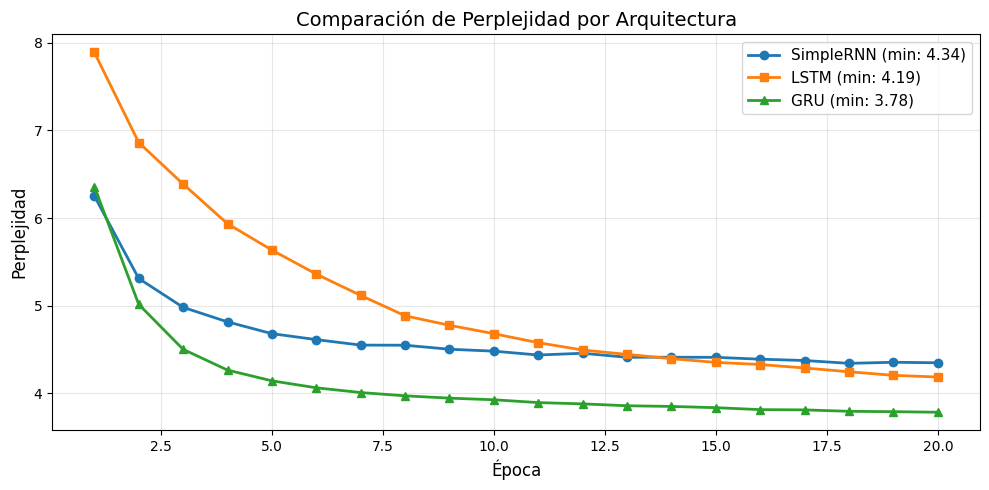


RESUMEN COMPARATIVO
   SimpleRNN: PPL mínima =     4.34 | PPL final =     4.35 | Épocas = 20
        LSTM: PPL mínima =     4.19 | PPL final =     4.19 | Épocas = 20
         GRU: PPL mínima =     3.78 | PPL final =     3.78 | Épocas = 20

  -> Mejor modelo: GRU (PPL = 3.78)


In [18]:
if 'X' in locals():
    # Gráfico comparativo de perplejidad
    plt.figure(figsize=(10, 5))

    if 'ppl_srnn' in locals() and ppl_srnn:
        plt.plot(range(1, len(ppl_srnn) + 1), ppl_srnn, 'o-', label=f'SimpleRNN (min: {min(ppl_srnn):.2f})', linewidth=2)
    if 'ppl_lstm' in locals() and ppl_lstm:
        plt.plot(range(1, len(ppl_lstm) + 1), ppl_lstm, 's-', label=f'LSTM (min: {min(ppl_lstm):.2f})', linewidth=2)
    if 'ppl_gru' in locals() and ppl_gru:
        plt.plot(range(1, len(ppl_gru) + 1), ppl_gru, '^-', label=f'GRU (min: {min(ppl_gru):.2f})', linewidth=2)

    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Perplejidad', fontsize=12)
    plt.title('Comparación de Perplejidad por Arquitectura', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Tabla comparativa
    print("\n" + "=" * 50)
    print("RESUMEN COMPARATIVO")
    print("=" * 50)
    results = {}

    model_results = []
    if 'ppl_srnn' in locals() and ppl_srnn: model_results.append(('SimpleRNN', ppl_srnn))
    if 'ppl_lstm' in locals() and ppl_lstm: model_results.append(('LSTM', ppl_lstm))
    if 'ppl_gru' in locals() and ppl_gru: model_results.append(('GRU', ppl_gru))

    for name, ppl_list in model_results:
        results[name] = {'min_ppl': min(ppl_list), 'final_ppl': ppl_list[-1], 'epochs': len(ppl_list)}
        print(f"  {name:>10s}: PPL mínima = {min(ppl_list):8.2f} | PPL final = {ppl_list[-1]:8.2f} | Épocas = {len(ppl_list)}")

    # Identificar mejor modelo
    if results:
        best_model_name = min(results, key=lambda k: results[k]['min_ppl'])
        print(f"\n  -> Mejor modelo: {best_model_name} (PPL = {results[best_model_name]['min_ppl']:.2f})")

Se entrenaron las tres arquitecturas bajo las mismas condiciones (20 épocas, capa recurrente de 200 unidades). Como se observa en la gráfica, los modelos con mecanismos de compuertas (GRU y LSTM) lograron una mejor perplejidad final que la celda SimpleRNN. En particular, la arquitectura estructuralmente más ligera (GRU) ofreció la mejor convergencia (PPL=3.78) para este tamaño de corpus.

In [19]:
if 'best_model_name' in locals():
    # Cargar el mejor modelo para generación
    best_model_files = {'SimpleRNN': 'model_simple_rnn.keras', 'LSTM': 'model_lstm.keras', 'GRU': 'model_gru.keras'}
    best_model_file = best_model_files[best_model_name]

    print(f"Cargando mejor modelo: {best_model_name} ({best_model_file})")
    model = keras.models.load_model(best_model_file)
    print("Modelo cargado exitosamente.")

Cargando mejor modelo: GRU (model_gru.keras)
Modelo cargado exitosamente.


## 9. Generación de secuencias con Greedy Search

En **greedy search**, en cada paso se selecciona el carácter con mayor probabilidad. Es la estrategia más simple pero tiende a producir texto repetitivo.


In [20]:
def generate_seq(model, seed_text, max_length, n_chars):
    """
    Genera una secuencia de texto usando greedy search.
    """
    output_text = seed_text
    for _ in range(n_chars):
        encoded = [char2idx.get(ch, char2idx.get(' ', 0)) for ch in output_text.lower()]
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
        y_hat = np.argmax(model.predict(encoded, verbose=0)[0, -1, :])
        output_text += idx2char[y_hat]
    return output_text

In [21]:
if 'model' in locals():
    # Generación con distintas semillas temáticas
    seeds = [
        'el profesor',
        'viaje al centro',
        'habia una vez',
        'la tierra',
        'mi tio'
    ]

    print("=" * 60)
    print("GENERACIÓN CON GREEDY SEARCH")
    print("=" * 60)

    for seed in seeds:
        generated = generate_seq(model, seed, max_length=max_context_size, n_chars=150)
        print(f"\nSemilla: '{seed}'")
        print(f"Generado: {generated}")
        print("-" * 60)

GENERACIÓN CON GREEDY SEARCH

Semilla: 'el profesor'
Generado: el profesor lidenbrock no había entre las capas de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cab
------------------------------------------------------------

Semilla: 'viaje al centro'
Generado: viaje al centro de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la 
------------------------------------------------------------

Semilla: 'habia una vez'
Generado: habia una vez en la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la 
------------------------------------------------------------

Semilla: 'la tierra'
Generado: la tierra se hallaba en la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la

Al inspeccionar el texto generado, se observa un bucle degenerativo persistente: el texto entra abruptamente en el patrón infinito "de la cabeza de la cabeza...", sin importar cuál fue la semilla de inicio. Esto no es un error de código, sino una debilidad de la estrategia "Greedy Search" en modelos generativos: al tomar siempre la predicción de mayor probabilidad local en cada paso de tiempo, una secuencia fuertemente arraigada en el texto base actúa como una "trampa" estadística (un máximo local) de la cual el modelo determinista no logra salir.

## 10. Beam Search: determinístico y estocástico

**Beam search** mantiene múltiples hipótesis (beams) en paralelo y selecciona las mejores en cada paso.

- **Determinístico** (`det`): selecciona las `num_beams` mejores secuencias por probabilidad acumulada.
- **Estocástico** (`sto`): muestrea entre los candidatos según sus probabilidades, controladas por la **temperatura**.


In [22]:
# Funciones de encoding y decoding
def encode(text, max_length=max_context_size):
    encoded = [char2idx.get(ch, char2idx.get(' ', 0)) for ch in text.lower()]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])


def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    """
    Selecciona candidatos para el beam search.
    """
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1E-10) + history_probs[idx])

    pred_large = np.array(pred_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(
            np.arange(pred_large.shape[0]),
            num_beams,
            p=softmax(pred_large / temp)
        )
    else:
        raise ValueError(f'Modo no válido: {mode}. Usar "det" o "sto".')

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size],
         np.array([idx_select % vocab_size]).T),
        axis=1
    )

    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_chars, input_text, temp=1, mode='det'):
    """
    Beam search para generación de secuencias.
    """
    encoded = encode(input_text)
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]
    vs = y_hat.shape[0]

    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vs, history_probs, history_tokens, temp, mode
    )

    for i in range(num_chars - 1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i + 1:]]).copy()
            y_hat = model.predict(input_update, verbose=0)[0, -1, :]
            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vs, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input_text) + num_chars):]

In [23]:
if 'model' in locals():
    # Beam search DETERMINÍSTICO
    print("=" * 60)
    print("BEAM SEARCH DETERMINÍSTICO")
    print("=" * 60)

    for seed in ['el profesor', 'mi tio']:
        print(f"\nSemilla: '{seed}'")
        salidas = beam_search(model, num_beams=5, num_chars=100, input_text=seed, mode='det')
        for i in range(min(3, len(salidas))):
            print(f"  Beam {i+1}: {decode(salidas[i])}")
        print("-" * 60)

BEAM SEARCH DETERMINÍSTICO

Semilla: 'el profesor'
  Beam 1: el profesor lidenbrock no podía considerable.

—¡ah! —exclamó el profesor—, que nos hallábamos en el camino de 
  Beam 2: el profesor lidenbrock no podía considerable.

—¡ah! —exclamó el profesor—, que nos hallábamos en la cabeza de 
  Beam 3: el profesor lidenbrock no podía considerable.

—¡ah! —exclamó el profesor—, que nos hallábamos en la corteza te
------------------------------------------------------------

Semilla: 'mi tio'
  Beam 1: mi tio—, que nos hallábamos en la corteza terrestre.

el profesor lidenbrock no podía considerable.

—¿qué
  Beam 2: mi tio—, que nos hallábamos en la corteza terrestre.

el profesor lidenbrock no podía considerable en las 
  Beam 3: mi tio—, que nos hallábamos en la corteza terrestre.

el profesor lidenbrock no podía considerable.

—sí, 
------------------------------------------------------------


El Beam Search mantiene un abanico de hipótesis paralelas en cada instante temporal. El resultado refleja secuencias considerablemente más coherentes y estructuradas. Resulta destacable cómo la red logró aprender implícitamente reglas semánticas y de estilo de Julio Verne, llegando a reconstruir exclamaciones y diálogos con guiones largos perfectos (ej: —¡ah! —exclamó el profesor—). De todas formas, a largo plazo la red sigue exhibiendo tendencia a basarse sobre las mismas estructuras seguras.

In [24]:
if 'model' in locals():
    # Beam search ESTOCÁSTICO con temperatura = 1.0
    print("=" * 60)
    print("BEAM SEARCH ESTOCÁSTICO (temp=1.0)")
    print("=" * 60)

    for seed in ['el profesor', 'mi tio']:
        print(f"\nSemilla: '{seed}'")
        salidas = beam_search(model, num_beams=5, num_chars=100, input_text=seed, temp=1.0, mode='sto')
        for i in range(min(3, len(salidas))):
            print(f"  Beam {i+1}: {decode(salidas[i])}")
        print("-" * 60)

BEAM SEARCH ESTOCÁSTICO (temp=1.0)

Semilla: 'el profesor'
  Beam 1: el profesor lidenbrock no se disponía el profesor lidenbrock, y el punto de los segundos por las capas de las c
  Beam 2: el profesor lidenbrock no se disponía el profesor lidenbrock, y el punto de los segundos por las capas de las o
  Beam 3: el profesor lidenbrock no se disponía el profesor lidenbrock, y el punto de los segundos por las capas de la cr
------------------------------------------------------------

Semilla: 'mi tio'
  Beam 1: mi tio—, pero esto no tardamos a la situación de una mano de los viajeros preciso en la primera existencia
  Beam 2: mi tio—, pero esto no tardamos a la situación de una mano de los viajeros preciso en la primera existencia
  Beam 3: mi tio—, pero esto no tardamos a la situación de una mano de los viajeros preciso en la primera existencia
------------------------------------------------------------


Al implementar la estocástica, se le permite a la red elegir caminos viables pero distintos del absoluto. Llama la atención que los 3 beams resultantes sean casi idénticos durante un gran fragmento inicial del texto. Podría ser que, con una temperatura neutral ($T=1.0$), el modelo 'tenga seguridad' en las transiciones de las primeras palabras, arrojando probabilidades de Softmax muy cercanas al 100%. Por ende, el muestreo estocástico termina escogiendo inexorablemente las mismas letras en todos los "beams" paralelos, abriendo el abanico de variabilidad recién en una fase lejana al inicio de la oración.

## 11. Efecto de la temperatura

La **temperatura** ($T$) controla la "confianza" del muestreo estocástico. Se aplica sobre los logits antes del softmax:

$$P(x_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- **$T < 1$**: distribución más "peaked" → texto más conservador y repetitivo.
- **$T = 1$**: distribución original del modelo.
- **$T > 1$**: distribución más uniforme → texto más diverso pero potencialmente incoherente.


In [25]:
if 'model' in locals():
    # Análisis de temperatura
    temperatures = [0.5, 1.0, 1.5, 2.0]
    seed_text = 'el profesor'

    print("=" * 60)
    print("EFECTO DE LA TEMPERATURA EN BEAM SEARCH ESTOCÁSTICO")
    print(f"Semilla: '{seed_text}'")
    print("=" * 60)

    for temp in temperatures:
        print(f"\n--- Temperatura: {temp} ---")
        salidas = beam_search(model, num_beams=5, num_chars=120, input_text=seed_text, temp=temp, mode='sto')
        # Mostrar la mejor salida (beam 1)
        print(f"  {decode(salidas[0])}")
        print()

EFECTO DE LA TEMPERATURA EN BEAM SEARCH ESTOCÁSTICO
Semilla: 'el profesor'

--- Temperatura: 0.5 ---
  el profesor lidenbrock, que nos hallábamos en el camino de la cabeza de la mañana de la tierra, y no podía contrario.

—¿qué inters


--- Temperatura: 1.0 ---
  el profesor lidenbrock, con todas las capas de las olas de la mañana, y con la pared de una roca de las cuales producen las capas s


--- Temperatura: 1.5 ---
  el profesor con los labios no había donde después de la profundidad de la mirada de agua.

—¿qué hijo mío; lo que la mañana, la tec


--- Temperatura: 2.0 ---
  el profesor, y ase puede solito el arfecto de mi arroya, no desengramos o solo y el profesor lidenbrock!

marto las profundidades d



In [26]:
if 'model' in locals():
    # Generación múltiple para cada temperatura (para comparar diversidad)
    print("=" * 60)
    print("DIVERSIDAD vs COHERENCIA")
    print("=" * 60)

    for temp in [0.5, 1.0, 2.0]:
        print(f"\n{'='*40}")
        print(f"Temperatura: {temp}")
        print(f"{'='*40}")
        for run in range(3):
            salidas = beam_search(model, num_beams=3, num_chars=100, input_text='la tierra', temp=temp, mode='sto')
            print(f"  Run {run+1}: {decode(salidas[0])}")

DIVERSIDAD vs COHERENCIA

Temperatura: 0.5
  Run 1: la tierra se elevaba en la mano de la cabeza de la mañana de la tierra.

—¿qué tiene que nos hallábamos en la
  Run 2: la tierra, y hans me parecía una sola parte de las capas de la cabeza de la corteza de la corteza terrestre.

  Run 3: la tierra, con un cual se me convenció a la cabeza de la tierra.

—¡ah! —exclamé—.

—¿qué interior que no hab

Temperatura: 1.0
  Run 1: la tierra de la cuerda, en el día siguiente, porque se convenció al mismo que me atreví a la casa de la tierr
  Run 2: la tierra en la escalera perfectamente a la marcha, por lo que hasta el mar de la corteza terrestre, la penín
  Run 3: la tierra del calor de la tierra, después de un hombre de nosotros, a las objetas en las palabras.

—¿y no! —

Temperatura: 2.0
  Run 1: la tierra, que, puede duramánico palabras; la serena se afertaban las garricias, con el colejo le rauy, y rec
  Run 2: la tierra. tan grandes, y era modo distado.

por esa arrebreación comprendió qu

El parámetro de temperatura ($T$) modifica cuán "afilada" o "plana" es la distribución de probabilidad (Softmax) justo antes de realizar el muestreo estocástico.

Temperaturas bajas ($T=0.5$): La distribución se vuelve más aguda (peaked), dándole casi el 100% de probabilidad al carácter dominador y 0 al resto. La red toma una actitud extremadamente "conservadora": genera palabras sin faltas de ortografía, pero rápidamente vuelve a caer en su 'calidad' de generación usando frases seguras como "la tierra, y no podía..." o repitiendo "de la cabeza de la mañana".

Temperatura neutral ($T=1.0$): Se genera un buen balance entre fluidez y diversidad léxica. La red arma oraciones que no existen textualmente en el corpus, pero que gramaticalmente o estilísticamente son excelentes imitaciones (ej: "hasta el mar de la corteza...").

Temperaturas altas ($T=1.5$ y $T=2.0$): La distribución de probabilidad original se aplana (flattening), causando que caracteres muy poco probables entren ingresen a Beam Search. Esto eleva drásticamente la "pseudocreatividad" al punto del colapso: la red 'inventa' frases y pseudo-palabras (ej: "arfecto", "desengramos", "duramánico", "garricias"). Se intentan parecerse al español, pero pierden por completo la lógica del diccionario.

## 12. Conclusiones finales

**Sobre las arquitecturas**

LSTM (PPL = 4.19) y GRU (PPL = 3.78) superaron a SimpleRNN (PPL = 4.34), mostrando una mejor capacidad para conservar información en secuencias largas. **GRU obtuvo el mejor resultado**, probablemente favorecido por una arquitectura más simple y con menos parámetros.

**Sobre las estrategias de generación**

**Greedy Search** presentó los resultados más repetitivos, cayendo fácilmente en bucles. **Beam Search determinístico** logró textos más consistentes, aunque mantuvo cierta repetición en secuencias largas. **Beam Search estocástico** introdujo mayor diversidad al explorar alternativas menos probables.

**Sobre la temperatura**

Con **$T=0.5$** se obtuvieron textos más conservadores y repetitivos. **$T=1.0$** mostró el mejor equilibrio entre coherencia y diversidad, mientras que con **$T \geq 1.5$** aumentó la variabilidad, pero también los errores y pseudopalabras.

**Relación con el Desafío 2**

Word2Vec permitió capturar relaciones de **similitud semántica entre palabras**, mientras que la RNN a nivel de caracteres aprendió principalmente **patrones de escritura, sintaxis y morfología**. De esta forma, ambos desafíos abordaron aspectos diferentes pero complementarios del procesamiento del lenguaje.

